# FloraLens — Plant Disease Detection with Grad-CAM

A walkthrough of the FloraLens pipeline: data, splits, model, training,
evaluation and the Grad-CAM verification.

This notebook calls the same modules under `src/` that the command-line scripts
use, so nothing here is a separate reimplementation that could drift from what
actually produced the committed model.

Run order if you are starting from scratch:

```bash
python -m src.prepare_data --source data/raw
python scripts/fetch_backbone.py
python -m src.train
```

The cells below load the results of those steps.

## 1. Setup

In [1]:
import sys, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.config import CLASSES, IMAGE_SIZE, RESULTS_DIR
from src.data import LeafDataset, class_weights

print("torch", torch.__version__)
print("classes:", CLASSES)
print("input size:", IMAGE_SIZE)

torch 2.14.0+cu130
classes: ['Early Blight', 'Healthy', 'Late Blight']
input size: 224


## 2. The data

PlantVillage potato subset: early blight, late blight, healthy.

The class balance is the first thing worth looking at. Healthy leaves are a small
minority, and that shapes several later decisions — the loss weighting, and the
choice of macro F1 over accuracy for checkpoint selection.

In [2]:
import csv, collections

manifest = list(csv.DictReader(open(ROOT / "data" / "manifest.csv")))
counts = collections.Counter((r["split"], r["label"]) for r in manifest)

print(f"{'split':<8}" + "".join(f"{c:>15}" for c in CLASSES) + f"{'total':>9}")
for split in ("train", "val", "test"):
    row = [counts[(split, c)] for c in CLASSES]
    print(f"{split:<8}" + "".join(f"{v:>15}" for v in row) + f"{sum(row):>9}")

total = collections.Counter(r["label"] for r in manifest)
print("\noverall:", dict(total))
print(f"healthy is {100*total['Healthy']/len(manifest):.1f}% of the dataset")

split      Early Blight        Healthy    Late Blight    total
train               700            106            700     1506
val                 150             23            150      323
test                150             23            150      323

overall: {'Early Blight': 1000, 'Healthy': 152, 'Late Blight': 1000}
healthy is 7.1% of the dataset


### Split integrity

Before trusting any test number, check that the test set does not contain images
the model effectively saw during training.

Two passes, both recorded in `data/split_audit.json`:

- **exact duplicates** — MD5 of the file bytes
- **near duplicates** — a perceptual difference hash, compared pairwise across
  every image. PlantVillage holds several photographs of some physical leaves;
  those are not byte-identical, so MD5 alone would miss them.

"We checked and found nothing" and "we did not check" produce an identical
manifest, which is why the audit is written to disk rather than assumed.

In [3]:
audit = json.loads((ROOT / "data" / "split_audit.json").read_text())
for k in ("total_images", "unique_md5", "exact_duplicates_crossing_splits",
          "near_duplicate_threshold_bits", "near_duplicate_pairs_crossing_splits"):
    print(f"{k:<42} {audit[k]}")

total_images                               2152
unique_md5                                 2152
exact_duplicates_crossing_splits           0
near_duplicate_threshold_bits              4
near_duplicate_pairs_crossing_splits       0


### What the images look like

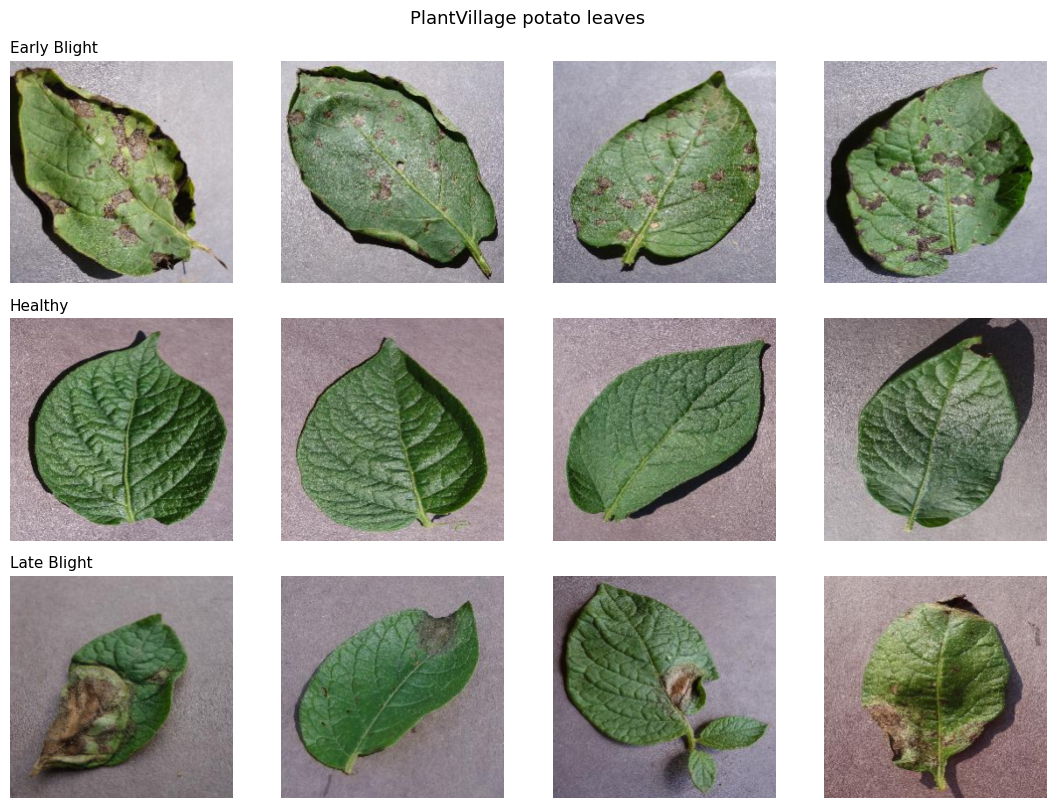

In [4]:
ds = LeafDataset("train", train_mode=False)
mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])

by_class = {}
for i in range(len(ds)):
    lab = int(ds.rows[i]["label_index"])
    by_class.setdefault(lab, []).append(i)
    if all(len(v) >= 4 for v in by_class.values()) and len(by_class) == len(CLASSES):
        break

fig, axes = plt.subplots(len(CLASSES), 4, figsize=(11, 8.2))
for r, cls in enumerate(sorted(by_class)):
    for c, idx in enumerate(by_class[cls][:4]):
        x, _ = ds[idx]
        img = np.clip(x.numpy().transpose(1, 2, 0) * std + mean, 0, 1)
        axes[r, c].imshow(img); axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(CLASSES[cls])
    axes[r, 0].set_title(CLASSES[cls], loc="left", fontsize=11)
plt.suptitle("PlantVillage potato leaves", fontsize=13)
plt.tight_layout(); plt.show()

Note the uniformity: one detached leaf per image, even lighting, plain
background. This is laboratory data, and it is the main reason the headline
accuracy should not be read as field performance.

## 3. Handling the imbalance

Inverse-frequency weights, normalised to average 1. Without them, the cheapest
way for the model to cut its loss is to under-predict the rare class — which is
backwards, since a missed healthy leaf means a false disease alarm.

In [5]:
w = class_weights("train")
for c, v in zip(CLASSES, w.tolist()):
    print(f"{c:<14} weight {v:.3f}")

Early Blight   weight 0.349
Healthy        weight 2.303
Late Blight    weight 0.349


## 4. The model, and why the head is so plain

MobileNetV3-Small backbone (ImageNet-pretrained) → global average pooling →
dropout → a single `Linear` layer.

That last part is a deliberate constraint rather than a simplification. With a
GAP → Linear head, Grad-CAM collapses to a closed form:

$$\alpha_k = \frac{1}{HW}\sum_{ij}\frac{\partial y_c}{\partial A_{kij}} = \frac{W_{ck}}{HW}
\qquad\Rightarrow\qquad
\mathrm{cam} = \mathrm{relu}\!\left(\sum_k W_{ck} A_k\right) \big/ HW$$

The channel weights Grad-CAM would obtain from gradients *are* the classifier
weights. The $1/HW$ is a positive constant and vanishes on normalisation.

The practical consequence: the browser can compute a real Grad-CAM with no
backward pass. The stock MobileNetV3 head (`Linear → Hardswish → Dropout →
Linear`) would break the equivalence.

In [6]:
from src.model import FloraLensNet
from src.evaluate import load_model

model = load_model(torch.device("cpu"))
logits, feats = model.forward_with_features(torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
print("logits  ", tuple(logits.shape))
print("features", tuple(feats.shape))
print("trainable parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

Loaded checkpoint from epoch 7 (val macro F1 1.0000)
logits   (1, 3)
features (1, 576, 7, 7)
trainable parameters: 928,739


## 5. Training

Run `python -m src.train`. Highlights:

- **Two learning rates** — 1e-4 for the backbone, which already knows edges and
  texture from ImageNet, 1e-3 for the randomly initialised head.
- **Checkpoint selection on validation macro F1**, not accuracy. A model that
  never predicts healthy still scores ~93% accuracy on this distribution while
  its macro F1 collapses.
- **The test split is never touched here.** It is read once, by
  `src/evaluate.py`, after training ends.

In [7]:
hist = json.loads((RESULTS_DIR / "training_history.json").read_text())
h = hist["history"]
print(f"best epoch {hist['best_epoch']}  val macro F1 {hist['best_val_macro_f1']:.4f}  "
      f"({hist['elapsed_seconds']/60:.1f} min on {hist['device']})\n")
print(f"{'ep':>3}{'train loss':>12}{'train acc':>11}{'val loss':>10}{'val acc':>9}{'val F1':>9}")
for e in h:
    print(f"{e['epoch']:>3}{e['train_loss']:>12.4f}{e['train_acc']:>11.4f}"
          f"{e['val_loss']:>10.4f}{e['val_acc']:>9.4f}{e['val_macro_f1']:>9.4f}")

best epoch 7  val macro F1 1.0000  (7.0 min on cpu)

 ep  train loss  train acc  val loss  val acc   val F1
  1      0.4525     0.8493    0.1103   0.9876   0.9789
  2      0.0835     0.9748    0.0407   0.9938   0.9896
  3      0.0399     0.9894    0.0318   0.9969   0.9918
  4      0.0232     0.9940    0.0169   0.9969   0.9918
  5      0.0349     0.9834    0.0184   0.9938   0.9896
  6      0.0288     0.9900    0.0231   0.9969   0.9918
  7      0.0220     0.9907    0.0097   1.0000   1.0000
  8      0.0199     0.9940    0.0089   1.0000   1.0000
  9      0.0114     0.9973    0.0067   1.0000   1.0000
 10      0.0132     0.9960    0.0057   1.0000   1.0000
 11      0.0154     0.9947    0.0108   1.0000   1.0000
 12      0.0194     0.9907    0.0065   1.0000   1.0000


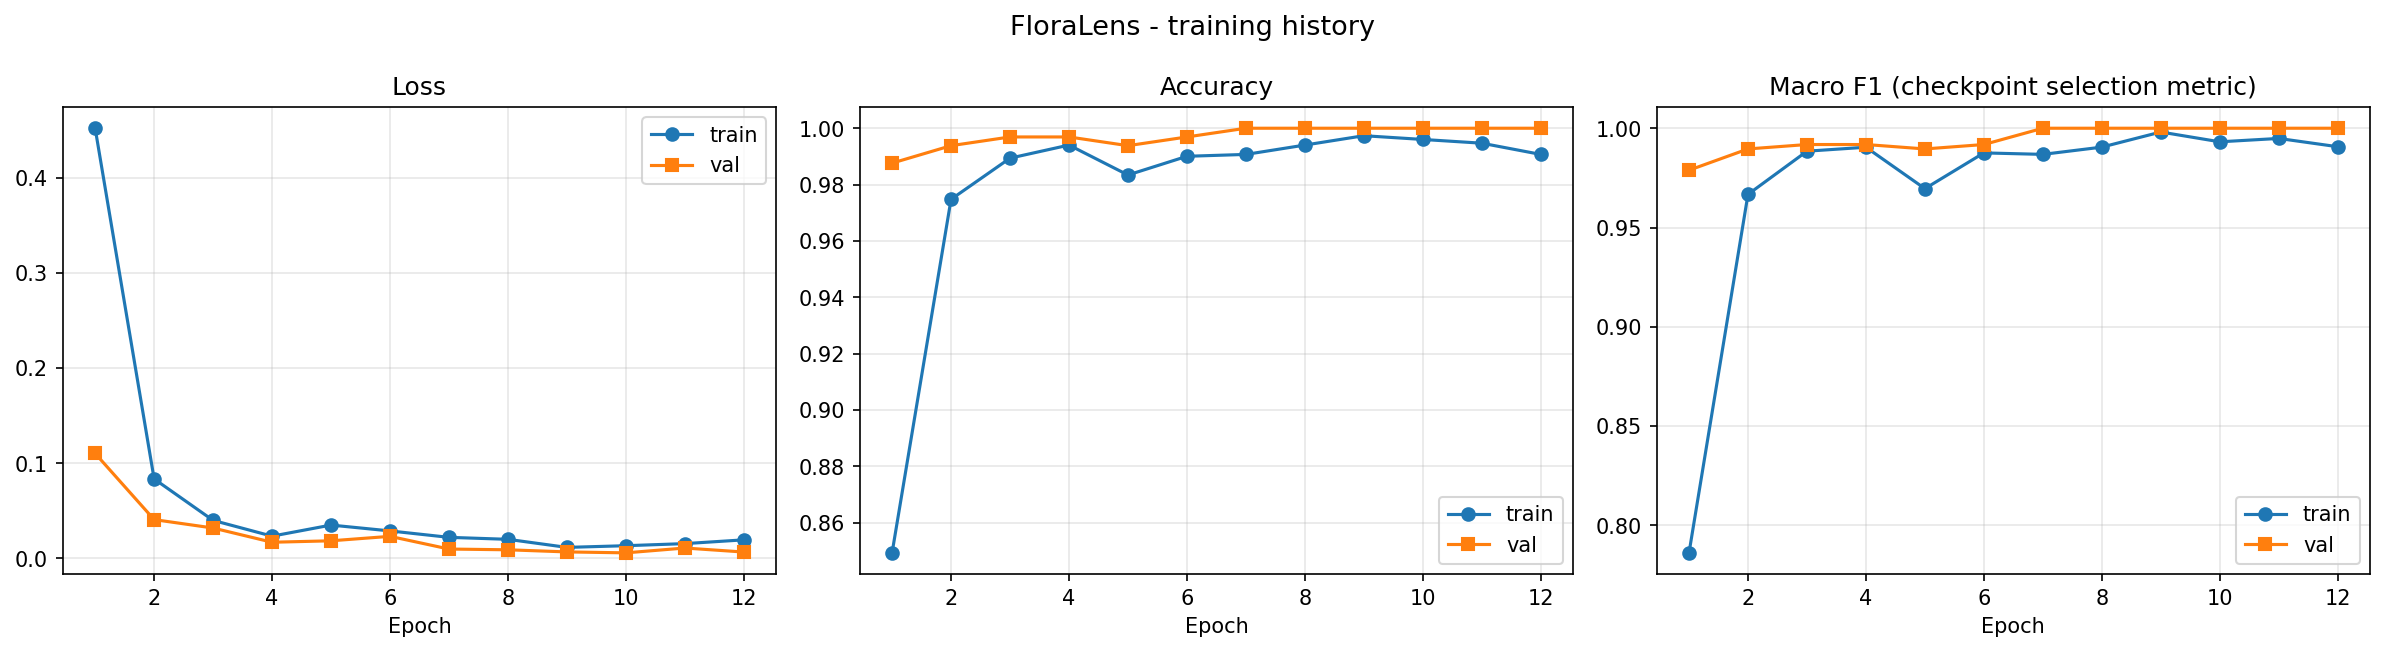

In [8]:
from IPython.display import Image, display
display(Image(filename=str(RESULTS_DIR / "plots" / "training_curves.png")))

## 6. Test set results

One pass over 323 held-out images.

In [9]:
m = json.loads((RESULTS_DIR / "metrics.json").read_text())
print(f"test accuracy {m['test_accuracy']:.4f}   macro F1 {m['macro_f1']:.4f}   "
      f"n = {m['n_test_images']}\n")
print(f"{'class':<14}{'precision':>11}{'recall':>9}{'f1':>8}{'support':>9}")
for c in CLASSES:
    p = m["per_class"][c]
    print(f"{c:<14}{p['precision']:>11.4f}{p['recall']:>9.4f}{p['f1']:>8.4f}{p['support']:>9}")

conf = m["confidence"]
print(f"\nmean confidence when correct: {conf['mean_when_correct']:.4f}")
print(f"mean confidence when wrong  : {conf['mean_when_wrong']:.4f}")
print(f"errors: {conf['n_wrong']} of {m['n_test_images']}")

test accuracy 0.9876   macro F1 0.9688   n = 323

class           precision   recall      f1  support
Early Blight       1.0000   1.0000  1.0000      150
Healthy            0.8519   1.0000  0.9200       23
Late Blight        1.0000   0.9733  0.9865      150

mean confidence when correct: 0.9921
mean confidence when wrong  : 0.6297
errors: 4 of 323


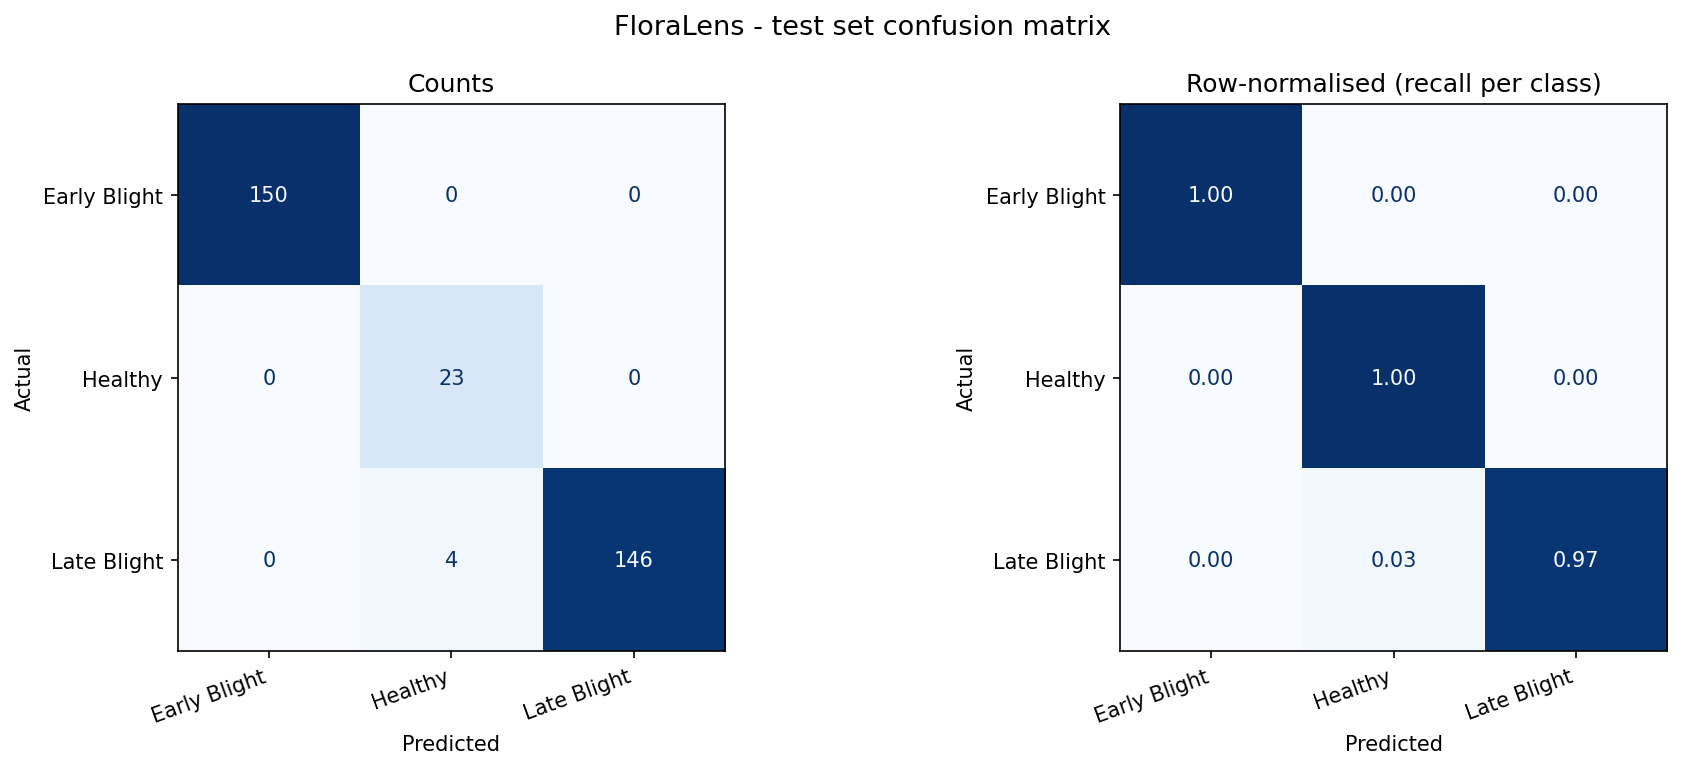

In [10]:
display(Image(filename=str(RESULTS_DIR / "plots" / "confusion_matrix.png")))

Every error is a late blight leaf called healthy — the costly direction, since a
missed infection spreads. Healthy recall is a perfect 1.000 while its precision
is 0.852, and both numbers describe the same four images: nothing healthy was
flagged as diseased, but four diseased leaves slipped into the healthy bucket.

The confidence gap is some comfort: 0.992 when right against 0.630 when wrong, so
the mistakes show up as hesitant rather than confidently wrong.

## 7. Verifying the Grad-CAM claim

The algebra in section 4 is easy to get subtly wrong, so it is checked
numerically instead of trusted. `src/verify_gradcam.py` runs the reference
autograd Grad-CAM and the closed form over 60 test images, and also compares the
exported ONNX model — the thing the browser actually runs — against PyTorch.

In [11]:
v = json.loads((RESULTS_DIR / "gradcam_verification.json").read_text())
a = v["autograd_vs_closed_form"]
print(f"images compared                  : {v['n_images']}")
print(f"max |CAM difference|             : {a['max_abs_cam_difference']:.3e}")
print(f"mean |CAM difference|            : {a['mean_abs_cam_difference']:.3e}")
print(f"predicted-class mismatches       : {a['predicted_class_mismatches']}")
if "onnx_vs_pytorch" in v:
    o = v["onnx_vs_pytorch"]
    print(f"ONNX vs PyTorch, max |logit diff|: {o['max_abs_logit_difference']:.3e}")
    print(f"ONNX vs PyTorch, max |CAM diff|  : {o['max_abs_cam_difference']:.3e}")
print(f"\ntolerance {v['tolerance']:g} -> {'PASS' if v['passed'] else 'FAIL'}")

images compared                  : 60
max |CAM difference|             : 2.980e-07
mean |CAM difference|            : 1.480e-07
predicted-class mismatches       : 0
ONNX vs PyTorch, max |logit diff|: 3.815e-06
ONNX vs PyTorch, max |CAM diff|  : 1.907e-06

tolerance 0.0001 -> PASS


## 8. Looking at the explanations

The point of the task. Below: the two Grad-CAM implementations side by side on
one image, then the model's mistakes.

In [12]:
from PIL import Image as PILImage
from src.gradcam import gradcam_autograd, gradcam_closed_form, cam_to_overlay

test_ds = LeafDataset("test", train_mode=False)
idx = 0
x, true_lab = test_ds[idx]
raw = np.array(PILImage.open(test_ds.image_path(test_ds.rows[idx]))
               .convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)))

cam_a, cls_a, probs_a = gradcam_autograd(model, x.unsqueeze(0))
cam_b, cls_b, _ = gradcam_closed_form(model, x.unsqueeze(0))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
axes[0].imshow(raw);                        axes[0].set_title(f"input\nactual: {CLASSES[true_lab]}")
axes[1].imshow(cam_to_overlay(cam_a, raw)); axes[1].set_title("Grad-CAM (autograd)")
axes[2].imshow(cam_to_overlay(cam_b, raw)); axes[2].set_title("Grad-CAM (closed form,\nthe browser's method)")
im = axes[3].imshow(np.abs(cam_a - cam_b), cmap="magma")
axes[3].set_title(f"absolute difference\nmax {np.abs(cam_a-cam_b).max():.2e}")
plt.colorbar(im, ax=axes[3], fraction=0.046)
for ax in axes[:3]: ax.axis("off")
axes[3].axis("off")
plt.suptitle(f"predicted {CLASSES[cls_a]} at {probs_a[cls_a]:.3f} confidence", fontsize=12)
plt.tight_layout(); plt.show()

The difference panel is numerical noise at the 1e-7 level — the two maps are the
same map.

### Where the model goes wrong

In [13]:
errors = []
for i in range(len(test_ds)):
    xi, li = test_ds[i]
    with torch.no_grad():
        p = torch.softmax(model(xi.unsqueeze(0)), 1)[0].numpy()
    if int(p.argmax()) != int(li):
        errors.append((i, int(li), int(p.argmax()), float(p.max())))

print(f"{len(errors)} misclassified test images\n")
fig, axes = plt.subplots(2, len(errors), figsize=(4.0*len(errors), 8.4))
axes = np.atleast_2d(axes)
for c, (i, true_l, pred_l, conf) in enumerate(errors):
    xi, _ = test_ds[i]
    img = np.array(PILImage.open(test_ds.image_path(test_ds.rows[i]))
                   .convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)))
    cam, _, _ = gradcam_autograd(model, xi.unsqueeze(0))
    axes[0, c].imshow(img); axes[0, c].axis("off")
    axes[0, c].set_title(f"actual: {CLASSES[true_l]}", fontsize=10)
    axes[1, c].imshow(cam_to_overlay(cam, img)); axes[1, c].axis("off")
    axes[1, c].set_title(f"said {CLASSES[pred_l]} ({conf:.2f})", fontsize=10, color="#c02026")
plt.suptitle("Every test-set error, with what the model was looking at", fontsize=13)
plt.tight_layout(); plt.show()

4 misclassified test images



This is the payoff of the task. The heatmaps sit on clean tissue toward the
middle of the leaf, while the late blight lesions on these particular leaves are
nearer the margins. The model did not fail randomly — it answered about the part
of the leaf it was attending to, and that part really was healthy.

Worth separating the observation from an explanation, though. Why attention
landed there is *not* established by these four pictures, and one tempting
explanation can be ruled out immediately: this is not a cropping artefact, since
`src/data.py` resizes the whole image to 224×224 without cropping, so the margins
are fully present in the input. What remains are hypotheses — the 7×7 feature
grid may be too coarse to isolate small marginal lesions, or these particular
leaves may have faint lesions, which their low confidences would be consistent
with. Separating those needs an experiment, not a closer look at four images.

## 9. Where this could go next

- **Higher input resolution**, which would test the "7×7 is too coarse"
  hypothesis directly: if a finer feature grid fixes these four, the grid was the
  constraint; if it does not, the explanation lies elsewhere.
- **Out-of-distribution rejection.** The model currently answers confidently for
  any image at all. A confidence threshold is a patch; an explicit OOD check is
  the fix.
- **Field images.** PlantVillage is laboratory data, and the gap to real
  photographs with soil, shadow and overlapping foliage is well documented.
- **More of PlantVillage.** The same pipeline extends to all 38 classes; potato
  was chosen to keep training to minutes on CPU.